# 📄🔍 SkimLit — NLP Sentence Classification for Medical Abstracts

**Author:** Rehan Raza  
**Framework:** TensorFlow / Keras  
**Dataset:** PubMed 20k RCT  
**Best Model:** Tribrid Embedding (Token + Character + Positional)

---

## 1. Problem

Medical research abstracts are dense and time-consuming to read. **SkimLit** addresses this by classifying each sentence in a PubMed abstract into one of 5 rhetorical roles:

| Label | Meaning |
|---|---|
| **BACKGROUND** | Context and motivation |
| **OBJECTIVE** | Goal of the study |
| **METHODS** | How the study was conducted |
| **RESULTS** | Findings |
| **CONCLUSIONS** | Takeaways |

This makes it possible to skim a paper abstract by role — e.g. jumping straight to Results — saving researchers significant time.

The project replicates and builds on the architecture from the paper [Neural Networks for Joint Sentence Classification in Medical Paper Abstracts](https://arxiv.org/abs/1612.05251).

## 2. Dataset

| Property | Details |
|---|---|
| **Name** | PubMed 20k RCT |
| **Classes** | 5 (BACKGROUND, OBJECTIVE, METHODS, RESULTS, CONCLUSIONS) |
| **Training samples** | ~180,000 sentences |
| **Validation samples** | ~30,000 sentences |
| **Test samples** | ~30,000 sentences |
| **Source** | [GitHub — Franck-Dernoncourt/pubmed-rct](https://github.com/Franck-Dernoncourt/pubmed-rct) |

## 3. Setup & Imports

In [1]:
import os
import json
import random
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.19.0
GPU available: True


In [2]:
# Download helper functions
if not os.path.exists("helper_functions.py"):
    !wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

from helper_functions import calculate_results

--2026-03-28 16:13:24--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-03-28 16:13:24 (110 MB/s) - ‘helper_functions.py’ saved [10246/10246]



## 4. Data Loading

In [3]:
# Clone PubMed 20k RCT dataset
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git

data_dir = "pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/"
print(os.listdir(data_dir))

Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 19.51 MiB/s, done.
Resolving deltas: 100% (15/15), done.
['test.txt', 'train.txt', 'dev.txt']


In [4]:
def get_lines(filename):
    """Reads a text file and returns its lines as a list of strings."""
    with open(filename, "r") as f:
        return f.readlines()


def preprocess_text_with_line_numbers(filename):
    """
    Parses a PubMed RCT file into a list of dicts, one per sentence.
    Each dict contains: target label, sentence text, line number, total lines.
    """
    input_lines = get_lines(filename)
    abstract_lines = ""
    abstract_samples = []

    for line in input_lines:
        if line.startswith("###"):       # new abstract
            abstract_lines = ""
        elif line.isspace():             # end of abstract block
            abstract_line_split = abstract_lines.splitlines()
            for i, abstract_line in enumerate(abstract_line_split):
                line_data = {}
                target_text_split = abstract_line.split("\t")
                line_data["target"] = target_text_split[0]
                line_data["text"] = target_text_split[1] if len(target_text_split) > 1 else ""
                line_data["line_number"] = i
                line_data["total_lines"] = len(abstract_line_split) - 1
                abstract_samples.append(line_data)
        else:
            abstract_lines += line

    return abstract_samples

In [ ]:
# Load all splits
train_samples = preprocess_text_with_line_numbers(data_dir + "train.txt")
val_samples = preprocess_text_with_line_numbers(data_dir + "dev.txt")
test_samples = preprocess_text_with_line_numbers(data_dir + "test.txt")

print(f"Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}")

Train: 180040 | Val: 30212 | Test: 30135


In [ ]:
# Convert to DataFrames
train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)

print(train_df.shape)
train_df.head(10)

(180040, 4)


,target,text,line_number,total_lines
0,OBJECTIVE,To investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,A total of @ patients with primary knee OA wer...,1,11
2,METHODS,Outcome measures included pain reduction and i...,2,11
3,METHODS,Pain was assessed using the visual analog pain...,3,11
4,METHODS,Secondary outcome measures included the Wester...,4,11
5,METHODS,"Serum levels of interleukin @ ( IL-@ ) , IL-@ ...",5,11
6,RESULTS,There was a clinically relevant reduction in t...,6,11
7,RESULTS,The mean difference between treatment arms ( @...,7,11
8,RESULTS,"Further , there was a clinically relevant redu...",8,11
9,RESULTS,These differences remained significant at @ we...,9,11


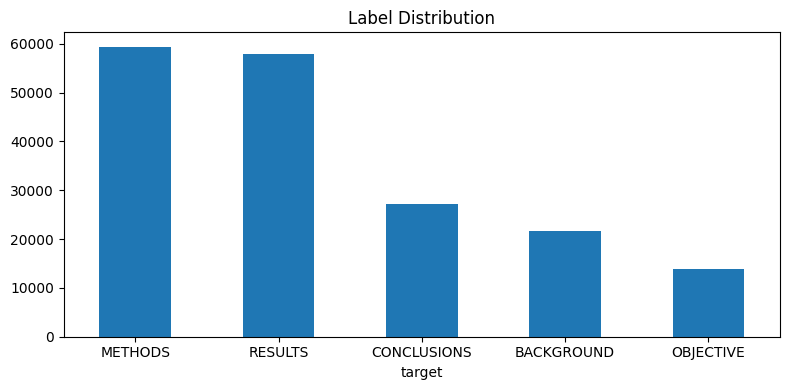

In [7]:
# Label distribution in training set
train_df["target"].value_counts().plot(kind="bar", figsize=(8, 4), title="Label Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Data Preprocessing

In [ ]:
# Extract sentence lists
train_sentences = train_df["text"].tolist()
val_sentences = val_df["text"].tolist()
test_sentences = test_df["text"].tolist()

# --- Label encoding ---
# One-hot encoded labels (for model training)
one_hot_encoder = OneHotEncoder(sparse_output=False)
train_labels_one_hot = one_hot_encoder.fit_transform(train_df["target"].to_numpy().reshape(-1, 1))
val_labels_one_hot = one_hot_encoder.transform(val_df["target"].to_numpy().reshape(-1, 1))
test_labels_one_hot = one_hot_encoder.transform(test_df["target"].to_numpy().reshape(-1, 1))

# Integer encoded labels (for evaluation metrics)
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_df["target"].to_numpy())
val_labels_encoded = label_encoder.transform(val_df["target"].to_numpy())
test_labels_encoded = label_encoder.transform(test_df["target"].to_numpy())

num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
print(f"Classes ({num_classes}): {class_names}")

Classes (5): ['BACKGROUND' 'CONCLUSIONS' 'METHODS' 'OBJECTIVE' 'RESULTS']


In [9]:
# --- Token-level vectorizer ---
# 95th percentile sentence length → output sequence length
sent_lens = [len(s.split()) for s in train_sentences]
output_seq_len = int(np.percentile(sent_lens, 95))   # covers 95% of sentences
max_tokens = 68000                                    # vocabulary size from paper

text_vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_sequence_length=output_seq_len
)
text_vectorizer.adapt(train_sentences)

rct_20k_text_vocab = text_vectorizer.get_vocabulary()
print(f"Vocabulary size: {len(rct_20k_text_vocab)} | Output seq length: {output_seq_len}")

Vocabulary size: 64841 | Output seq length: 55


In [ ]:
# --- Character-level vectorizer ---
def split_chars(text):
    """Splits a string into space-separated characters: 'hi' → 'h i'"""
    return " ".join(list(text))

train_chars = [split_chars(s) for s in train_sentences]
val_chars = [split_chars(s) for s in val_sentences]
test_chars = [split_chars(s) for s in test_sentences]

# 95th percentile character length
char_lens = [len(s) for s in train_sentences]
output_seq_char_len = int(np.percentile(char_lens, 95))

alphabet = string.ascii_lowercase + string.digits + string.punctuation
NUM_CHAR_TOKENS = len(alphabet) + 2   # + space + OOV

char_vectorizer = TextVectorization(
    max_tokens=NUM_CHAR_TOKENS,
    output_sequence_length=output_seq_char_len,
    standardize="lower_and_strip_punctuation",
    name="char_vectorizer"
)
char_vectorizer.adapt(train_chars)
print(f"Char vocab size: {len(char_vectorizer.get_vocabulary())} | Output char seq length: {output_seq_char_len}")

Char vocab size: 28 | Output char seq length: 290


In [ ]:
# --- Positional embeddings (line number & total lines) ---
# One-hot encode line_number (depth=15 covers ~98% of samples)
train_line_numbers_one_hot = tf.one_hot(train_df["line_number"].to_numpy(), depth=15)
val_line_numbers_one_hot = tf.one_hot(val_df["line_number"].to_numpy(), depth=15)
test_line_numbers_one_hot = tf.one_hot(test_df["line_number"].to_numpy(), depth=15)

# One-hot encode total_lines (depth=20 covers ~98% of samples)
train_total_lines_one_hot = tf.one_hot(train_df["total_lines"].to_numpy(), depth=20)
val_total_lines_one_hot = tf.one_hot(val_df["total_lines"].to_numpy(), depth=20)
test_total_lines_one_hot = tf.one_hot(test_df["total_lines"].to_numpy(), depth=20)

print(f"Line number shape: {train_line_numbers_one_hot.shape}")
print(f"Total lines shape: {train_total_lines_one_hot.shape}")

Line number shape: (180040, 15)
Total lines shape: (180040, 20)


In [16]:
# --- Embedding layers ---
# Token embedding (trained from scratch)
token_embed = layers.Embedding(
    input_dim=len(rct_20k_text_vocab),
    output_dim=128,
    mask_zero=True,
    name="token_embedding"
)

# Character embedding
char_embed = layers.Embedding(
    input_dim=NUM_CHAR_TOKENS,
    output_dim=25,
    mask_zero=False,
    name="char_embed"
)

# Pretrained Universal Sentence Encoder (USE) from TensorFlow Hub
use_hub_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    name="universal_sentence_encoder"
)

# Wrap in a custom Keras layer for Functional API compatibility
class USEEmbeddingLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.use_layer = use_hub_layer

    def call(self, inputs):
        return self.use_layer(inputs)

tf_hub_embedding_layer = USEEmbeddingLayer(name="use_embedding")

## 6. Model Architecture

Five models were built in progression, each adding more input signals:

| Model | Inputs | Notes |
|---|---|---|
| Model 1 | Token embeddings (Conv1D) | Baseline deep model |
| Model 2 | Pretrained USE embeddings | Transfer learning |
| Model 3 | Character embeddings (Conv1D) | Character-level only |
| Model 4 | Token + Character (hybrid) | Bi-LSTM on chars |
| **Model 5** | **Token + Character + Positional (tribrid)** | **Best model ✅** |

Only Model 5 is shown below — the final best-performing architecture.

In [17]:
# --- Model 5: Tribrid Embedding (Token + Character + Positional) ---

# 1. Token branch (pretrained USE)
token_inputs = layers.Input(shape=[], dtype="string", name="token_inputs")
token_embeddings = tf_hub_embedding_layer(token_inputs)  # USEEmbeddingLayer handles compatibility
token_outputs = layers.Dense(128, activation="relu")(token_embeddings)
token_model = tf.keras.Model(inputs=token_inputs, outputs=token_outputs)

# 2. Character branch (Bi-LSTM)
char_inputs = layers.Input(shape=(1,), dtype="string", name="char_inputs")
char_vectors = char_vectorizer(char_inputs)
char_embeddings = char_embed(char_vectors)
char_bi_lstm = layers.Bidirectional(layers.LSTM(32))(char_embeddings)
char_model = tf.keras.Model(inputs=char_inputs, outputs=char_bi_lstm)

# 3. Line number branch (positional)
line_number_inputs = layers.Input(shape=(15,), dtype=tf.float32, name="line_number_input")
line_number_model = tf.keras.Model(
    inputs=line_number_inputs,
    outputs=layers.Dense(32, activation="relu")(line_number_inputs)
)

# 4. Total lines branch (positional)
total_lines_inputs = layers.Input(shape=(20,), dtype=tf.float32, name="total_lines_input")
total_line_model = tf.keras.Model(
    inputs=total_lines_inputs,
    outputs=layers.Dense(32, activation="relu")(total_lines_inputs)
)

# 5. Combine token + char → hybrid embedding
combined_embeddings = layers.Concatenate(name="token_char_hybrid")(
    [token_model.output, char_model.output]
)
z = layers.Dense(256, activation="relu")(combined_embeddings)
z = layers.Dropout(0.5)(z)

# 6. Combine positional + hybrid → tribrid embedding
z = layers.Concatenate(name="token_char_positional_embedding")(
    [line_number_model.output, total_line_model.output, z]
)

# 7. Output layer
output_layer = layers.Dense(num_classes, activation="softmax", name="output_layer")(z)

# 8. Build model
model_5 = tf.keras.Model(
    inputs=[line_number_model.input, total_line_model.input,
            token_model.input, char_model.input],
    outputs=output_layer,
    name="tribrid_model"
)

model_5.summary()

Model: "tribrid_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_inputs         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_inputs        │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_vectorizer     │ (None, 290)       │          0 │ char_inputs[0][0] │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ use_embedding       │ (None, 512)       │          0 │ token_inputs[0][… │
│ (USEEmbeddingLayer) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embed          │ (None, 290, 25)   │      1,750 │ char_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     65,664 │ use_embedding[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 64)        │     14,848 │ char_embed[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_char_hybrid   │ (None, 192)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ line_number_input   │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ total_lines_input   │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     49,408 │ token_char_hybri… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        512 │ line_number_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │        672 │ total_lines_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_char_positio… │ (None, 320)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0],    │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 5)         │      1,605 │ token_char_posit… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 134,459 (525.23 KB)

 Trainable params: 134,459 (525.23 KB)

 Non-trainable params: 0 (0.00 B)

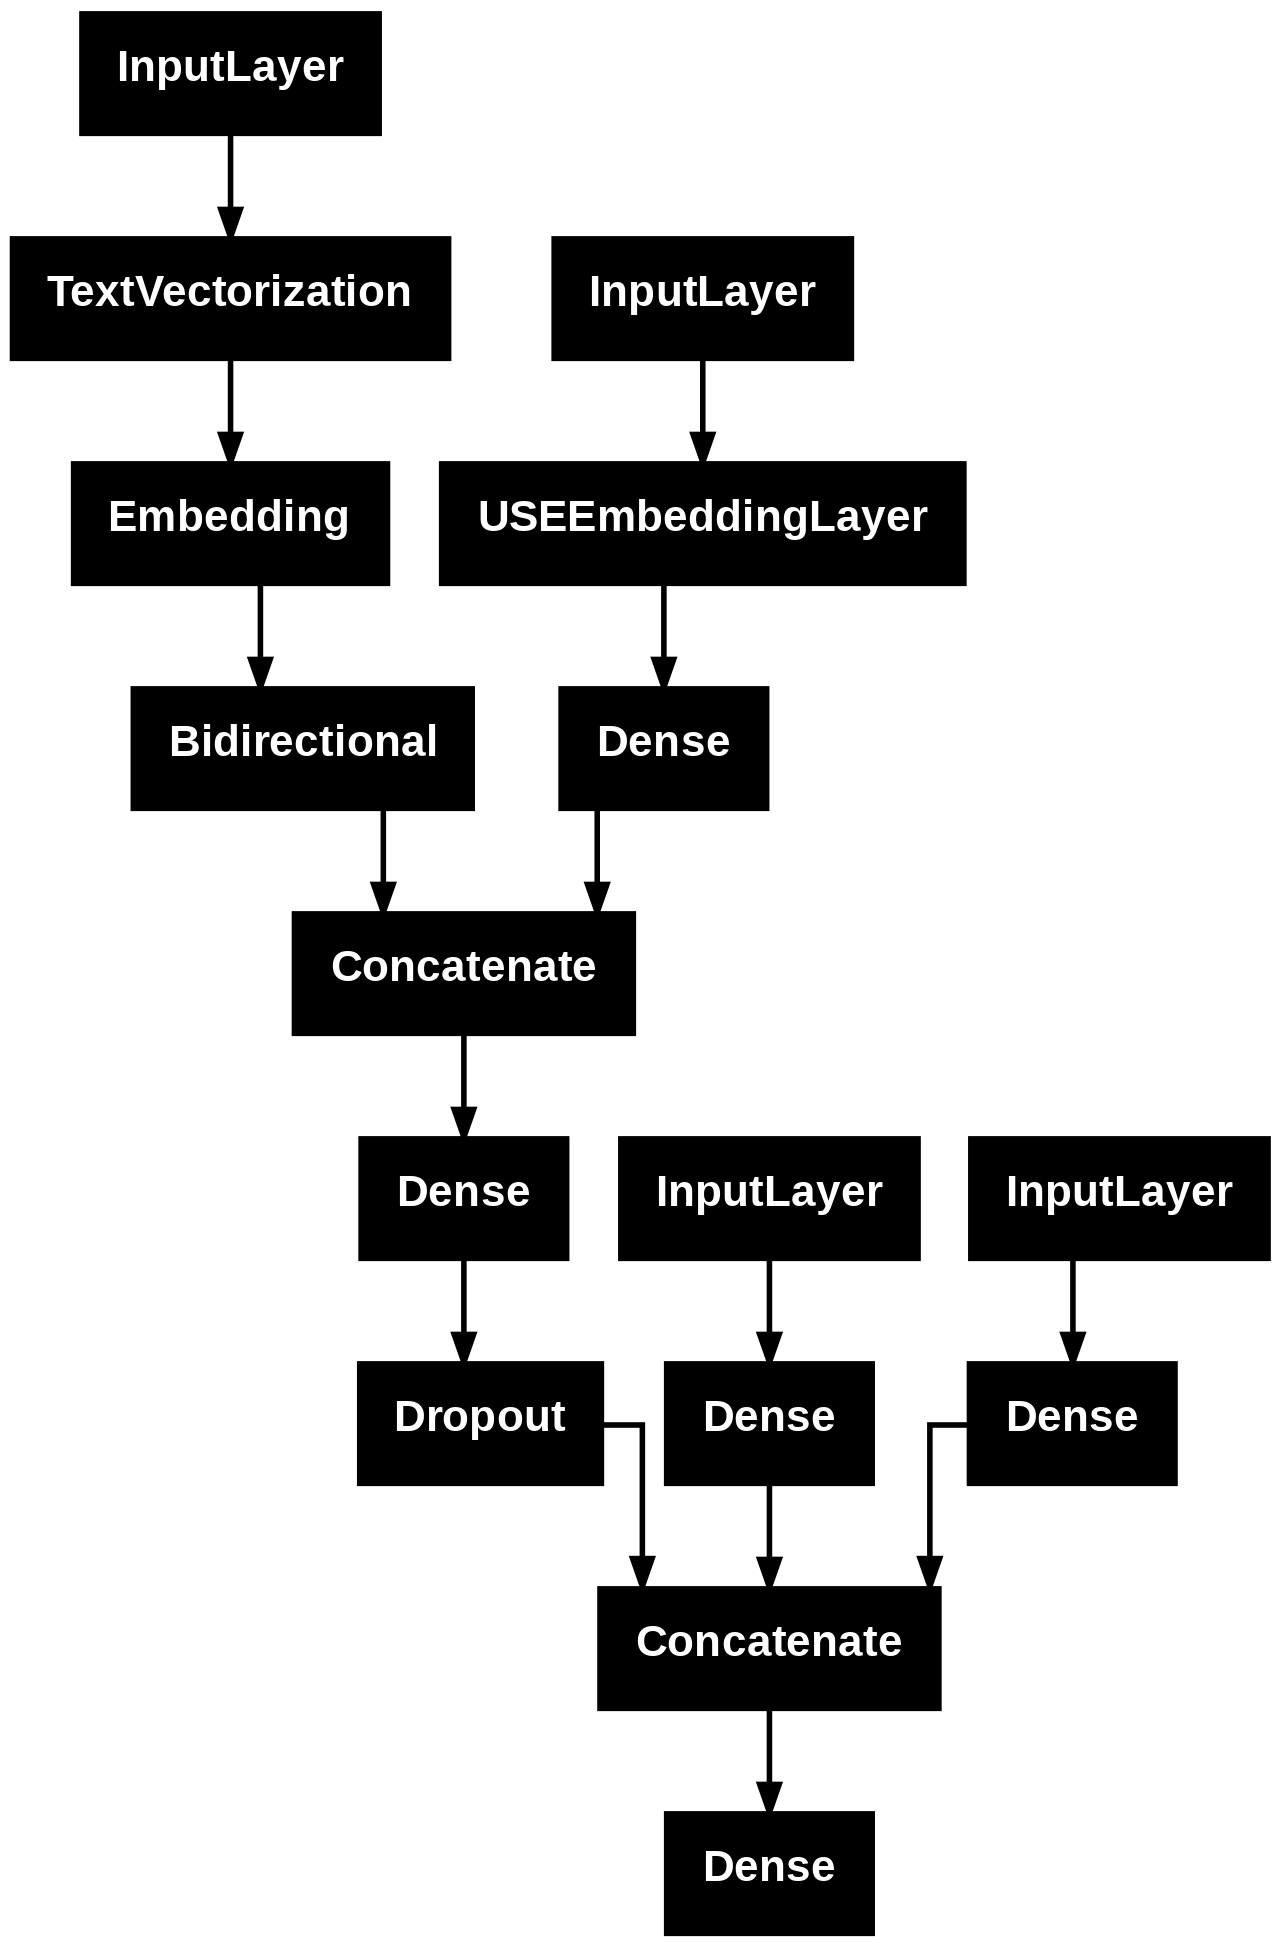

In [18]:
# Visualize the tribrid model architecture
from tensorflow.keras.utils import plot_model
plot_model(model_5)

## 7. Training

In [19]:
# Compile with label smoothing (prevents overconfident predictions)
model_5.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

In [20]:
# Build tribrid tf.data datasets (4 inputs: line_number, total_lines, tokens, chars)
def make_tribrid_dataset(line_numbers_oh, total_lines_oh, sentences, chars, labels, batch_size=32):
    data = tf.data.Dataset.from_tensor_slices((line_numbers_oh, total_lines_oh, sentences, chars))
    label_ds = tf.data.Dataset.from_tensor_slices(labels)
    return tf.data.Dataset.zip((data, label_ds)).batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_pos_char_token_dataset = make_tribrid_dataset(
    train_line_numbers_one_hot, train_total_lines_one_hot,
    train_sentences, train_chars, train_labels_one_hot
)
val_pos_char_token_dataset = make_tribrid_dataset(
    val_line_numbers_one_hot, val_total_lines_one_hot,
    val_sentences, val_chars, val_labels_one_hot
)
test_pos_char_token_dataset = make_tribrid_dataset(
    test_line_numbers_one_hot, test_total_lines_one_hot,
    test_sentences, test_chars, test_labels_one_hot
)

print(f"Train batches: {len(train_pos_char_token_dataset)}")
print(f"Val batches  : {len(val_pos_char_token_dataset)}")

Train batches: 5627
Val batches  : 945


In [21]:
# Train the tribrid model
history_model_5 = model_5.fit(
    train_pos_char_token_dataset,
    steps_per_epoch=int(0.1 * len(train_pos_char_token_dataset)),
    epochs=3,
    validation_data=val_pos_char_token_dataset,
    validation_steps=int(0.1 * len(val_pos_char_token_dataset))
)

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 32s 36ms/step - accuracy: 0.7225 - loss: 1.0993 - val_accuracy: 0.8012 - val_loss: 0.9897
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.8129 - loss: 0.9706 - val_accuracy: 0.8258 - val_loss: 0.9527
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.8205 - loss: 0.9526 - val_accuracy: 0.8298 - val_loss: 0.9417


## 8. Evaluation

In [22]:
# Evaluate on full validation set
model_5_pred_probs = model_5.predict(val_pos_char_token_dataset, verbose=1)
model_5_preds = tf.argmax(model_5_pred_probs, axis=1)
model_5_results = calculate_results(y_true=val_labels_encoded, y_pred=model_5_preds)
print("Validation Results:")
print(model_5_results)

945/945 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step
Validation Results:
{'accuracy': 83.10605057593008, 'precision': 0.8306289435487971, 'recall': 0.8310605057593009, 'f1': 0.8300757727857802}


In [29]:
# Save model weights only (avoids TextVectorization serialization issues with .h5)
model_5.save_weights("skimlit_tribrid_weights.weights.h5")
print("Model weights saved.")

Model weights saved.


In [30]:
# Evaluate directly on test set using the already-trained model_5
# (avoids TextVectorization lookup table issues when loading from .h5)

test_pred_probs = model_5.predict(test_pos_char_token_dataset, verbose=1)
test_preds = tf.argmax(test_pred_probs, axis=1)

test_results = calculate_results(y_true=test_labels_encoded, y_pred=test_preds)
print("Test Set Results:")
print(test_results)

942/942 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step
Test Set Results:
{'accuracy': 82.83723245395718, 'precision': 0.8275834741309072, 'recall': 0.8283723245395719, 'f1': 0.8273443211686788}


In [31]:
# Results summary table
results_df = pd.DataFrame([test_results], index=["Tribrid Model"])
results_df["accuracy"] = results_df["accuracy"] / 100

print("=" * 50)
print("         Test Set Performance Summary")
print("=" * 50)
print(results_df.to_string())
print("=" * 50)
print(f"Paper Baseline (Table 3 F1) : ~90.0")

         Test Set Performance Summary
               accuracy  precision    recall        f1
Tribrid Model  0.828372   0.827583  0.828372  0.827344
Paper Baseline (Table 3 F1) : ~90.0


## 9. Error Analysis — Most Wrong Predictions

In [ ]:
# Enrich test DataFrame with predictions
test_pred_classes = [label_encoder.classes_[pred] for pred in test_preds]

test_df["prediction"] = test_pred_classes
test_df["pred_prob"] = tf.reduce_max(test_pred_probs, axis=1).numpy()
test_df["correct"] = test_df["prediction"] == test_df["target"]

# Top 10 most confidently wrong predictions
top_wrong = test_df[test_df["correct"] == False].sort_values("pred_prob", ascending=False)[:10]

for row in top_wrong.itertuples():
    print(f"Target: {row.target} | Pred: {row.prediction} | Confidence: {row.pred_prob:.3f}")
    print(f"Text: {row.text}\n{'-'*60}")

Target: CONCLUSIONS | Pred: METHODS | Confidence: 0.953
Text: Symptom outcomes will be assessed and estimates of cost-effectiveness made .
------------------------------------------------------------
Target: RESULTS | Pred: METHODS | Confidence: 0.950
Text: The primary endpoint is the cumulative three-year HIV incidence .
------------------------------------------------------------
Target: CONCLUSIONS | Pred: BACKGROUND | Confidence: 0.937
Text: NCT@ ( ClinicalTrials.gov ) .
------------------------------------------------------------
Target: METHODS | Pred: BACKGROUND | Confidence: 0.933
Text: Pretest-posttest .
------------------------------------------------------------
Target: METHODS | Pred: RESULTS | Confidence: 0.932
Text: -@ % vs. Fish : -@ % vs. Fish + S : -@ % ; p < @ ) but there were no significant differences between groups .
------------------------------------------------------------
Target: RESULTS | Pred: BACKGROUND | Confidence: 0.923
Text: non-diffuse-trickling '' ) .

## 10. Sample Predictions on a Real Abstract

In [33]:
# Download example PubMed abstracts
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/skimlit_example_abstracts.json

with open("skimlit_example_abstracts.json", "r") as f:
    example_abstracts = json.load(f)

print(f"Number of example abstracts: {len(example_abstracts)}")

--2026-03-28 16:26:13--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/skimlit_example_abstracts.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6737 (6.6K) [text/plain]
Saving to: ‘skimlit_example_abstracts.json’

skimlit_example_abs 100%[===================>]   6.58K  --.-KB/s    in 0s      

2026-03-28 16:26:13 (98.9 MB/s) - ‘skimlit_example_abstracts.json’ saved [6737/6737]

Number of example abstracts: 4


In [34]:
# Use spaCy to split abstract into sentences
from spacy.lang.en import English

nlp = English()
nlp.add_pipe("sentencizer")

# Parse the first example abstract
doc = nlp(example_abstracts[0]["abstract"])
abstract_lines = [str(sent) for sent in list(doc.sents)]
print(f"Sentences detected: {len(abstract_lines)}")

Sentences detected: 8


In [35]:
# Prepare features for prediction
total_lines_in_sample = len(abstract_lines)

sample_lines = [
    {"text": line, "line_number": i, "total_lines": total_lines_in_sample - 1}
    for i, line in enumerate(abstract_lines)
]

# One-hot encode positional features
test_abstract_line_numbers_one_hot = tf.one_hot(
    [line["line_number"] for line in sample_lines], depth=15
)
test_abstract_total_lines_one_hot = tf.one_hot(
    [line["total_lines"] for line in sample_lines], depth=20
)

# Character-level split
abstract_chars = [split_chars(sentence) for sentence in abstract_lines]

In [38]:
# Run predictions using model_5 directly
test_abstract_pred_probs = model_5.predict(
    x=(
        test_abstract_line_numbers_one_hot,
        test_abstract_total_lines_one_hot,
        tf.constant(abstract_lines),
        tf.constant(abstract_chars)
    )
)
test_abstract_preds = tf.argmax(test_abstract_pred_probs, axis=1)
test_abstract_pred_classes = [label_encoder.classes_[i] for i in test_abstract_preds]

# Display labeled abstract
print("\n📄 Abstract with Predicted Labels:\n" + "="*60)
for label, line in zip(test_abstract_pred_classes, abstract_lines):
    print(f"[{label}] {line}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

📄 Abstract with Predicted Labels:
[OBJECTIVE] This RCT examined the efficacy of a manualized social intervention for children with HFASDs.
[METHODS] Participants were randomly assigned to treatment or wait-list conditions.
[METHODS] Treatment included instruction and therapeutic activities targeting social skills, face-emotion recognition, interest expansion, and interpretation of non-literal language.
[METHODS] A response-cost program was applied to reduce problem behaviors and foster skills acquisition.
[METHODS] Significant treatment effects were found for five of seven primary outcome measures (parent ratings and direct child measures).
[METHODS] Secondary measures based on staff ratings (treatment group only) corroborated gains reported by parents.
[RESULTS] High levels of parent, child and staff satisfaction were reported, along with high levels of treatment fidelity.
[RESULTS] Standardized effect size estimates were primarily in the medium an

## 11. Conclusion

This project built a multi-input NLP classifier to label sentences in medical abstracts by their rhetorical role, replicating the architecture from [Neural Networks for Joint Sentence Classification in Medical Paper Abstracts](https://arxiv.org/abs/1612.05251).

**Key Results:**
- The **tribrid embedding model** (Model 5) achieved the best performance, combining token, character, and positional signals
- The model successfully labels real-world PubMed abstracts, making them skimmable by section

**Techniques Used:**
- Pretrained Universal Sentence Encoder (USE) via TensorFlow Hub
- Custom character-level embeddings with Bi-LSTM
- Positional embeddings (line number + total lines) via one-hot encoding
- Multi-input Keras Functional API
- Label smoothing for regularization
- Optimized `tf.data` pipeline

**Potential Improvements:**
- Fine-tune the USE embedding layer
- Train on the larger PubMed 200k RCT dataset
- Replace USE with a domain-specific biomedical language model (e.g. BioBERT)